# GPU streaming-instability tests (128 cells per wavelength)

This notebook builds and runs the 128-cpw linA and linB streaming-instability tests with the Kokkos CUDA backend. For PPMX at this resolution, the validated conservative CFL is **0.225**.

## Test setup

### Problem generator

Both cases use the built-in `streaming_linear` problem generator in `athenak/src/pgen/tests/streaming_linear.cpp`. It initializes a two-dimensional radial–vertical shearing box with one dust species in the NSH equilibrium, adds a linear streaming-instability eigenmode, and records its Fourier amplitude through user-history output.

AthenaK is compiled with `-DPROBLEM=built_in_pgens`; each input selects this problem at runtime with `<problem>/pgen_name = streaming_linear`.

### CUDA build

From the project directory:

```bash
cmake -S athenak -B athenak/build-gpu \
  -DCMAKE_BUILD_TYPE=Release \
  -DPROBLEM=built_in_pgens \
  -DKokkos_ENABLE_CUDA=ON \
  -DKokkos_ARCH_<GPU_ARCH>=ON \
  -DCMAKE_CXX_COMPILER="$PWD/athenak/kokkos/bin/nvcc_wrapper"
cmake --build athenak/build-gpu -j
```

Replace `<GPU_ARCH>` with the appropriate Kokkos architecture option. The executable is written to `athenak/build-gpu/src/athena`. The notebook performs the same build if the executable is missing; rebuild explicitly after source changes.

### Inputs and execution

Tracked reference inputs are stored at:

```text
athenak_dust_tests/inputs/streaming_linA_128.athinput
athenak_dust_tests/inputs/streaming_linB_128.athinput
```

They contain the complete physical configuration and eigenmode parameters. The notebook independently recomputes the eigenmodes and writes runtime input copies under `athenak/build-gpu/run-dust/si_gpu/`.

Start Jupyter from the project directory, open this notebook, and select **Run All**. Missing or incomplete cases are run, completed histories are reused, and histories, logs, and figures remain under `athenak/build-gpu/run-dust/si_gpu/`.

In [1]:
import subprocess
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT/'athenak').is_dir() and (ROOT/'athenak_cc'/'athenak').is_dir():
    ROOT = ROOT/'athenak_cc'
assert (ROOT/'athenak').is_dir(), 'start Jupyter from athenak_cc or its parent'
ATHENAK = ROOT/'athenak'
BUILD = ATHENAK/'build-gpu'
ATHENA_GPU = BUILD/'src'/'athena'
WORK = BUILD/'run-dust'/'si_gpu'
WORK.mkdir(parents=True, exist_ok=True)
CUDA_ARCH = 'ADA89'

def build_gpu():
    wrapper = ATHENAK/'kokkos'/'bin'/'nvcc_wrapper'
    configure = [
        'cmake', '-S', str(ATHENAK), '-B', str(BUILD),
        '-DCMAKE_BUILD_TYPE=Release', '-DPROBLEM=built_in_pgens',
        '-DKokkos_ENABLE_CUDA=ON', f'-DKokkos_ARCH_{CUDA_ARCH}=ON',
        f'-DCMAKE_CXX_COMPILER={wrapper}',
    ]
    subprocess.run(configure, check=True)
    subprocess.run(['cmake', '--build', str(BUILD), '-j8'], check=True)

if not ATHENA_GPU.exists():
    build_gpu()
gpu = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,driver_version,memory.total',
     '--format=csv,noheader'], capture_output=True, text=True, check=True
).stdout.strip()
config = subprocess.run([str(ATHENA_GPU), '-c'], capture_output=True, text=True, check=True).stdout.strip()
print('GPU:', gpu)
print(config)
print('executable:', ATHENA_GPU)
print('work directory:', WORK)

GPU: NVIDIA GeForce RTX 4080 Laptop GPU, 610.62, 12282 MiB
This Athena++ executable is configured with:
  Problem generator:          built_in_pgens
  Floating-point precision:   double
  MPI parallelism:            OFF
  OpenMP parallelism:         OFF
executable: /home/rixin/Documents/Dropbox/ProgramOS/xpruns/athenak_dp/athenak_cc/athenak/build-gpu/src/athena
work directory: /home/rixin/Documents/Dropbox/ProgramOS/xpruns/athenak_dp/athenak_cc/athenak/build-gpu/run-dust/si_gpu


## Linear modes and generated inputs

The eigenproblem and normalization are the same as the validated implementation in `shearing_box_tests.ipynb`. The growing eigenpair is pinned to the high-precision reference rather than selected with `argmax(Im omega)`.

In [2]:
WREF_A = 0.3480182 + 0.4190091j
WREF_B = -0.4998788 + 0.0154862j

def nsh_drift(Om, q, ax, eps, taus):
    ns = len(eps); n = 2 + 2*ns
    A = np.zeros((n,n)); b = np.zeros(n)
    A[0,1] = 2*Om
    for s in range(ns):
        A[0,0] -= eps[s]/taus[s]; A[0,2+2*s] += eps[s]/taus[s]
    b[0] = -ax
    A[1,0] = -(2-q)*Om
    for s in range(ns):
        A[1,1] -= eps[s]/taus[s]; A[1,3+2*s] += eps[s]/taus[s]
    for s in range(ns):
        rx, rp = 2+2*s, 3+2*s
        A[rx,rp] = 2*Om; A[rx,rx] -= 1/taus[s]; A[rx,0] += 1/taus[s]
        A[rp,rx] = -(2-q)*Om; A[rp,rp] -= 1/taus[s]; A[rp,1] += 1/taus[s]
    return np.linalg.solve(A,b)

def si_eigen(Kx, Kz, taus, eps, w_ref, etavk=0.05, Om=1.0, cs=1.0, q=1.5):
    kx = Kx*Om/etavk; kz = Kz*Om/etavk
    Ux, Uy, Vx, Vy = nsh_drift(Om, q, 2*Om*etavk, [eps], [taus])
    ts = taus/Om
    A = np.zeros((8,8), dtype=complex)
    A[0,0]=kx*Ux; A[0,1]=kx; A[0,3]=kz
    A[1,1]=kx*Ux + 1j*(-eps/ts); A[1,2]=1j*2*Om
    A[1,0]=kx*cs**2 + 1j*(-(eps/ts)*(Vx-Ux)); A[1,4]=1j*((eps/ts)*(Vx-Ux)); A[1,5]=1j*(eps/ts)
    A[2,2]=kx*Ux + 1j*(-eps/ts); A[2,1]=1j*(-(2-q)*Om)
    A[2,0]=1j*(-(eps/ts)*(Vy-Uy)); A[2,4]=1j*((eps/ts)*(Vy-Uy)); A[2,6]=1j*(eps/ts)
    A[3,3]=kx*Ux + 1j*(-eps/ts); A[3,0]=kz*cs**2; A[3,7]=1j*(eps/ts)
    A[4,4]=kx*Vx; A[4,5]=kx; A[4,7]=kz
    A[5,5]=kx*Vx + 1j*(-1/ts); A[5,6]=1j*2*Om; A[5,1]=1j*(1/ts)
    A[6,6]=kx*Vx + 1j*(-1/ts); A[6,5]=1j*(-(2-q)*Om); A[6,2]=1j*(1/ts)
    A[7,7]=kx*Vx + 1j*(-1/ts); A[7,3]=1j*(1/ts)
    w, V = np.linalg.eig(A)
    i = int(np.argmin(np.abs(w - w_ref)))
    return w[i], V[:,i], (Ux, Uy, Vx, Vy, kx, kz)

for label, args in [('linA', (30,30,0.1,3.0,WREF_A)), ('linB', (6,6,0.1,0.2,WREF_B))]:
    w, _, _ = si_eigen(*args)
    print(f'{label}: omega = {w:.7f}')

linA: omega = 0.3480182+0.4190091j
linB: omega = -0.4998788+0.0154862j


In [3]:
def si_input(name, Kx, Kz, eps, tlim, w_ref, nx=128, taus=0.1, cfl=0.225,
             etavk=0.05, Om=1.0, cs=1.0, q=1.5, rho0=1.0, amp=1e-6):
    om, v, bg = si_eigen(Kx, Kz, taus, eps, w_ref, etavk, Om, cs, q)
    v = v*(amp/v[4])
    lamx, lamz = 2*np.pi/bg[4], 2*np.pi/bg[5]
    F = float
    amps = {
        'drhog_re': F(v[0].real*rho0), 'drhog_im': F(v[0].imag*rho0),
        'dugx_re': F(v[1].real), 'dugx_im': F(v[1].imag),
        'dugp_re': F(v[2].real), 'dugp_im': F(v[2].imag),
        'dugz_re': F(v[3].real), 'dugz_im': F(v[3].imag),
        'drhop_re': F(v[4].real*eps*rho0),
        'dvpx_re': F(v[5].real), 'dvpx_im': F(v[5].imag),
        'dvpp_re': F(v[6].real), 'dvpp_im': F(v[6].imag),
        'dvpz_re': F(v[7].real), 'dvpz_im': F(v[7].imag),
    }
    amp_lines = chr(10).join(f'{k} = {value!r}' for k, value in amps.items())
    return f'''
<job>
basename = {name}
<mesh>
nghost = 3
nx1 = {nx}
x1min = 0.0
x1max = {F(lamx)!r}
ix1_bc = periodic
ox1_bc = periodic
nx2 = {nx}
x2min = 0.0
x2max = {F(lamz)!r}
ix2_bc = periodic
ox2_bc = periodic
nx3 = 1
x3min = -0.5
x3max = 0.5
ix3_bc = periodic
ox3_bc = periodic
<meshblock>
nx1 = 32
nx2 = 32
nx3 = 1
<time>
evolution = dynamic
integrator = imex2+
cfl_number = {cfl}
nlim = -1
tlim = {F(tlim)!r}
ndiag = 100000
<hydro>
eos = isothermal
iso_sound_speed = {F(cs)!r}
reconstruct = ppmx
rsolver = roe
<hydro_srcterms>
const_accel = true
const_accel_val = {F(2*Om*etavk)!r}
const_accel_dir = 1
<shearing_box>
qshear = {F(q)!r}
omega0 = {F(Om)!r}
<particles>
particle_type = dust
pusher = imex_dust
ppc = 1.0
<dust>
nspecies = 1
taus_1 = {F(taus)!r}
dust_to_gas = {F(eps)!r}
back_reaction = true
deposit = tsc
gamma_switch = false
dt_cfl = 0.5
<problem>
pgen_name = streaming_linear
user_hist = true
rho0 = {F(rho0)!r}
etavk = {F(etavk)!r}
eps = {F(eps)!r}
kx = {F(bg[4])!r}
kz = {F(bg[5])!r}
omega_re = {F(om.real)!r}
{amp_lines}
<output1>
file_type = hst
dcycle = 100
data_format = %.14e
'''

CASES = {
    'gpu_linA128x': dict(Kx=30, Kz=30, eps=3.0, tlim=10.0, w_ref=WREF_A, window=(3.0,9.0)),
    'gpu_linB128x': dict(Kx=6, Kz=6, eps=0.2, tlim=8.0, w_ref=WREF_B, window=(0.0,6.0)),
}
for name, case in CASES.items():
    text = si_input(name, case['Kx'], case['Kz'], case['eps'], case['tlim'], case['w_ref'])
    (WORK/f'{name}.athinput').write_text(text)
    print('wrote', WORK/f'{name}.athinput')

wrote /home/rixin/Documents/Dropbox/ProgramOS/xpruns/athenak_dp/athenak_cc/athenak/build-gpu/run-dust/si_gpu/gpu_linA128x.athinput
wrote /home/rixin/Documents/Dropbox/ProgramOS/xpruns/athenak_dp/athenak_cc/athenak/build-gpu/run-dust/si_gpu/gpu_linB128x.athinput


## Run the two GPU cases

Completed histories are reused. An incomplete history is removed and rerun from the beginning because these compact tests do not write restart files. Runtime depends strongly on the GPU and build configuration.

In [4]:
def history_complete(path, tlim):
    if not path.exists():
        return False
    data = np.atleast_2d(np.loadtxt(path))
    return data[-1,0] >= tlim*(1.0 - 1e-12)

def run_gpu_case(name, case):
    hst = WORK/f'{name}.user.hst'
    if history_complete(hst, case['tlim']):
        print(f'{name}: reusing complete history through t={np.loadtxt(hst)[-1,0]:g}')
        return 0.0
    for suffix in ('user.hst', 'hydro.hst'):
        (WORK/f'{name}.{suffix}').unlink(missing_ok=True)
    log = WORK/f'{name}.log'
    tic = time.perf_counter()
    with log.open('w') as stream:
        result = subprocess.run(
            [str(ATHENA_GPU), '-i', str(WORK/f'{name}.athinput')],
            cwd=WORK, stdout=stream, stderr=subprocess.STDOUT, text=True
        )
    elapsed = time.perf_counter() - tic
    if result.returncode != 0:
        print(log.read_text()[-3000:])
        raise RuntimeError(f'{name} failed; see {log}')
    print(f'{name}: completed in {elapsed/60:.2f} minutes')
    return elapsed

timings = {name: run_gpu_case(name, case) for name, case in CASES.items()}

gpu_linA128x: reusing complete history through t=10
gpu_linB128x: reusing complete history through t=8


## Growth-rate validation

In [5]:
def growth_rate(path, window):
    data = np.atleast_2d(np.loadtxt(path))
    t = data[:,0]
    amplitude = np.hypot(data[:,2], data[:,3])
    use = (t >= window[0]) & (t <= window[1])
    assert use.sum() >= 3
    return np.polyfit(t[use], np.log(amplitude[use]), 1)[0], t, amplitude

measured = {}
for name, case in CASES.items():
    s, _, _ = growth_rate(WORK/f'{name}.user.hst', case['window'])
    measured[name] = s
    target = case['w_ref'].imag
    print(f'{name}: s = {s:.7f}, analytic = {target:.7f}, error = {(s/target-1)*100:+.3f}%')

assert 0.410 < measured['gpu_linA128x'] < 0.425
assert 0.0140 < measured['gpu_linB128x'] < 0.0165
print('PASS: both 128-cpw GPU growth rates are in the expected converged ranges')

gpu_linA128x: s = 0.4175955, analytic = 0.4190091, error = -0.337%
gpu_linB128x: s = 0.0153757, analytic = 0.0154862, error = -0.714%
PASS: both 128-cpw GPU growth rates are in the expected converged ranges


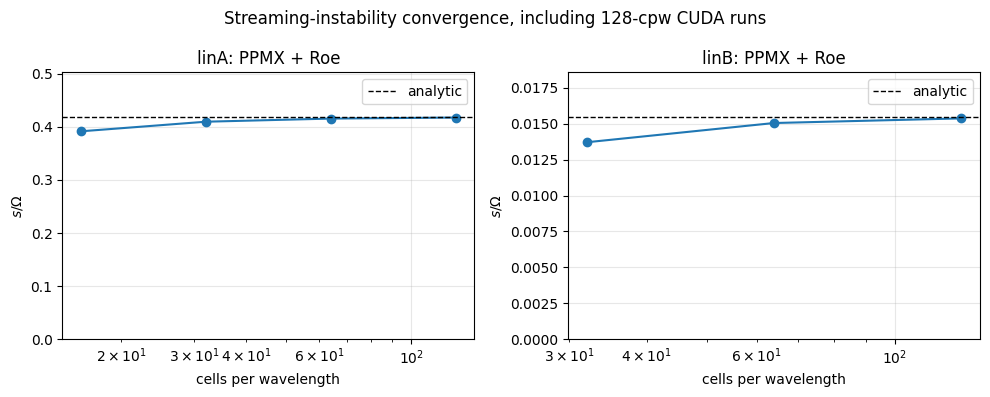

In [6]:
reference = ATHENAK/'build'/'run-dust'
series = {
    'linA': [('linA16x.user.hst',16), ('linA32x.user.hst',32), ('linA64x.user.hst',64)],
    'linB': [('linB32x.user.hst',32), ('linB64x.user.hst',64)],
}
windows = {'linA':(3.0,9.0), 'linB':(0.0,6.0)}
targets = {'linA':WREF_A.imag, 'linB':WREF_B.imag}
gpu_names = {'linA':'gpu_linA128x', 'linB':'gpu_linB128x'}
fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax, label in zip(axes, ('linA','linB')):
    points = []
    for filename, cpw in series[label]:
        path = reference/filename
        if path.exists():
            points.append((cpw, growth_rate(path, windows[label])[0]))
    points.append((128, measured[gpu_names[label]]))
    points.sort()
    ax.semilogx([p[0] for p in points], [p[1] for p in points], 'o-')
    ax.axhline(targets[label], color='k', ls='--', lw=1, label='analytic')
    ax.set(title=f'{label}: PPMX + Roe', xlabel='cells per wavelength', ylabel=r'$s/\Omega$')
    ax.set_ylim(0.0, 1.2*targets[label])
    ax.grid(alpha=0.3); ax.legend()
fig.suptitle('Streaming-instability convergence, including 128-cpw CUDA runs')
fig.tight_layout()
fig.savefig(WORK/'si_gpu_convergence.png', dpi=150)
plt.show()

In [7]:
cpu_ref = reference/'linA16x.user.hst'
gpu_smoke = WORK/'gpu_linA16_smoke.user.hst'
if cpu_ref.exists() and gpu_smoke.exists():
    cpu = np.atleast_2d(np.loadtxt(cpu_ref))
    gpu = np.atleast_2d(np.loadtxt(gpu_smoke))
    n = min(len(cpu), len(gpu))
    # A tlim-clipped final row need not align with the reference's regular dcycle row.
    while n and abs(cpu[n-1,0] - gpu[n-1,0]) > 1e-12:
        n -= 1
    assert n >= 10
    assert np.allclose(cpu[:n,0], gpu[:n,0], rtol=0, atol=1e-14)
    scale = np.max(np.hypot(cpu[:n,2], cpu[:n,3]))
    rel = np.max(np.abs(cpu[:n,2:4] - gpu[:n,2:4]))/scale
    print(f'16-cpw serial/GPU dust-mode difference: {rel:.3e} relative')
    assert rel < 1e-7
    print('PASS: serial and CUDA histories agree to reduction-order roundoff')
else:
    print('Optional serial/GPU smoke histories are not both present; comparison skipped.')

16-cpw serial/GPU dust-mode difference: 8.771e-09 relative
PASS: serial and CUDA histories agree to reduction-order roundoff


## Result

If the assertions above pass, the dust-particle module is working with the Kokkos CUDA backend for the 128-cpw linA/linB tests. The generated `.athinput`, `.hst`, log, and convergence plot files are retained in `athenak/build-gpu/run-dust/si_gpu/`.